<a href="https://colab.research.google.com/github/sreeakhilkolachina/Development-of-Interactive-Cyber-Threat-Visualization-Dashboard/blob/main/ai_generated_cyber_threats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PROJECT TITLE: AI-GENERATED CYBER THREAT DETECTION AND ANALYSIS SYSTEM

INTRODUCTION: This project focuses on the development of an AI-Generated Cyber Threat Detection and Analysis System that utilizes synthetic data generated through AI prompting techniques. The dataset simulates real-world cyber-attack scenarios, including attack types, severity levels, affected systems, detection tools, and response times. By using Python for data analysis and SQL for structured querying, the project aims to identify patterns, trends, and high-risk cyber threats.

PROMPT USED FOR DATASET CREATION: Open Source AI

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [ ]:
df = pd.read_csv("ai_generated_cyber_threats.csv")
df.head()


,Threat_ID,Timestamp,Source_IP,Destination_IP,Protocol,Port,Packet_Size,Login_Attempts,Failed_Attempts,Malware_Detected,Traffic_Type,Threat_Label
0,T001,2023-01-10 10:15,192.168.1.10,10.0.0.5,TCP,80,450,2,0,No,Normal,0
1,T002,2023-01-10 10:18,192.168.1.15,10.0.0.8,UDP,53,1200,1,0,No,Normal,0
2,T003,2023-01-11 09:45,172.16.0.4,10.0.0.20,TCP,22,300,15,10,No,Suspicious,1
3,T004,2023-01-11 10:05,172.16.0.9,10.0.0.25,TCP,443,800,3,1,No,Normal,0
4,T005,2023-01-12 14:30,203.0.113.5,10.0.0.30,TCP,3389,1500,20,18,No,Attack,1


In [ ]:
print(df.info())
print(df.describe())
print(df['Threat_Label'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Threat_ID         10 non-null     object
 1   Timestamp         10 non-null     object
 2   Source_IP         10 non-null     object
 3   Destination_IP    10 non-null     object
 4   Protocol          10 non-null     object
 5   Port              10 non-null     int64 
 6   Packet_Size       10 non-null     int64 
 7   Login_Attempts    10 non-null     int64 
 8   Failed_Attempts   10 non-null     int64 
 9   Malware_Detected  10 non-null     object
 10  Traffic_Type      10 non-null     object
 11  Threat_Label      10 non-null     int64 
dtypes: int64(5), object(7)
memory usage: 1.1+ KB
None
              Port  Packet_Size  Login_Attempts  Failed_Attempts  Threat_Label
count    10.000000    10.000000       10.000000        10.000000     10.000000
mean    471.900000   915.000000        9.

In [ ]:
label_encoder = LabelEncoder()

categorical_cols = ['Protocol', 'Malware_Detected', 'Traffic_Type']

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])


In [ ]:
X = df[['Port', 'Packet_Size', 'Login_Attempts', 'Failed_Attempts',
        'Protocol', 'Malware_Detected', 'Traffic_Type']]

y = df['Threat_Label']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



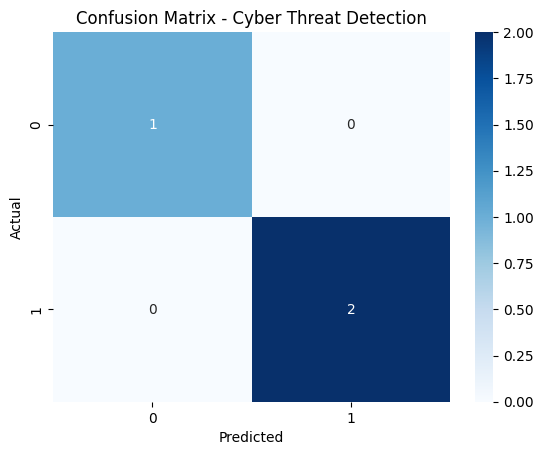

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Cyber Threat Detection")
plt.show()
